# Predicting Median House Values for Property Investment Decisions

This dataset comes from the 1990 California census and contains demographic and housing data for districts across the state. The goal is to predict median house values using a linear regression model, providing a data-driven baseline for property investment and valuation decisions. The notebook covers EDA, preprocessing, model training, and evaluation. The dataset has 20,640 samples and 8 features.

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

## Dataset

Loading the dataset from sklearn and exploring its structure

In [27]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()

print(f'Shape: {df.shape}')
print()
df.info()
df.describe()

Shape: (20640, 9)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## Feature Reference

| Feature | Description | Unit | Notes |
|---------|-------------|------|-------|
| `MedInc` | Median household income in the block group | $10,000s | Strongest predictor of house value |
| `HouseAge` | Median age of houses in the block group | Years | Capped at 52 |
| `AveRooms` | Average number of rooms per household | Rooms | Outliers present â€” max 141.9 |
| `AveBedrms` | Average number of bedrooms per household | Bedrooms | Outliers present â€” max 34.1 |
| `Population` | Total block group population | People | Wide range: 3 to 35,682 |
| `AveOccup` | Average number of occupants per household | People | Outliers present â€” max 1,243 |
| `Latitude` | Geographic latitude of the block group | Degrees | Southern CA: ~32â€“34, Northern CA: ~37â€“42 |
| `Longitude` | Geographic longitude of the block group | Degrees | Range: -124 to -114 |

**Target variable:** `MedHouseVal` â€” median house value, expressed in units of $100,000.
Values above $500,000 were recorded as 5.0 at the time of data collection. This censoring
will be visible in the target distribution.

## Exploratory Data Analysis

Before modelling, we examine the distribution of the target variable and the
relationships between features and house values.

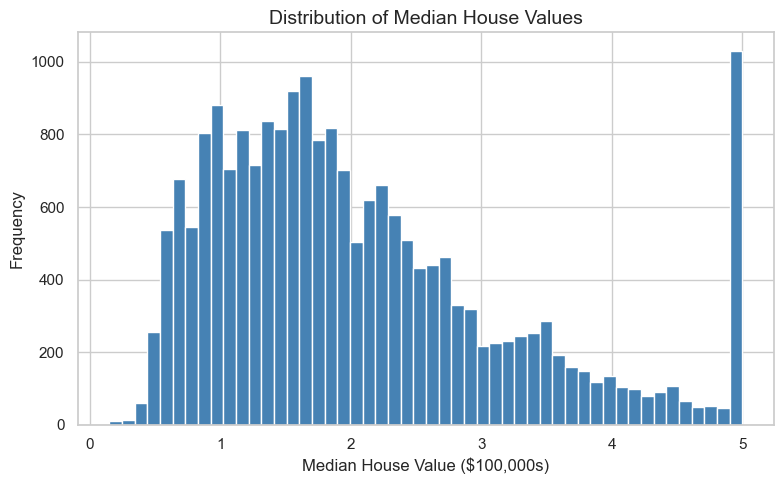

In [28]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(df['MedHouseVal'], bins=50, color='steelblue', edgecolor='white')

ax.set_title('Distribution of Median House Values', fontsize=14)
ax.set_xlabel('Median House Value ($100,000s)')
ax.set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('images/target_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

## Observations from Median House Value Distribution

- The distribution is right-skewed, with most properties falling between $100k and $300k. The higher-value tail pulls the mean ($206k) above the median ($180k). A log transformation of the target would reduce this skew and could improve model fit.

- A sharp spike at $500k reflects data censoring: values above that threshold were recorded as 5.0. Higher-value properties are underrepresented, which will affect predictions at the top end.

- 75% of properties are valued below approximately $265k. The model will perform most reliably in this range.

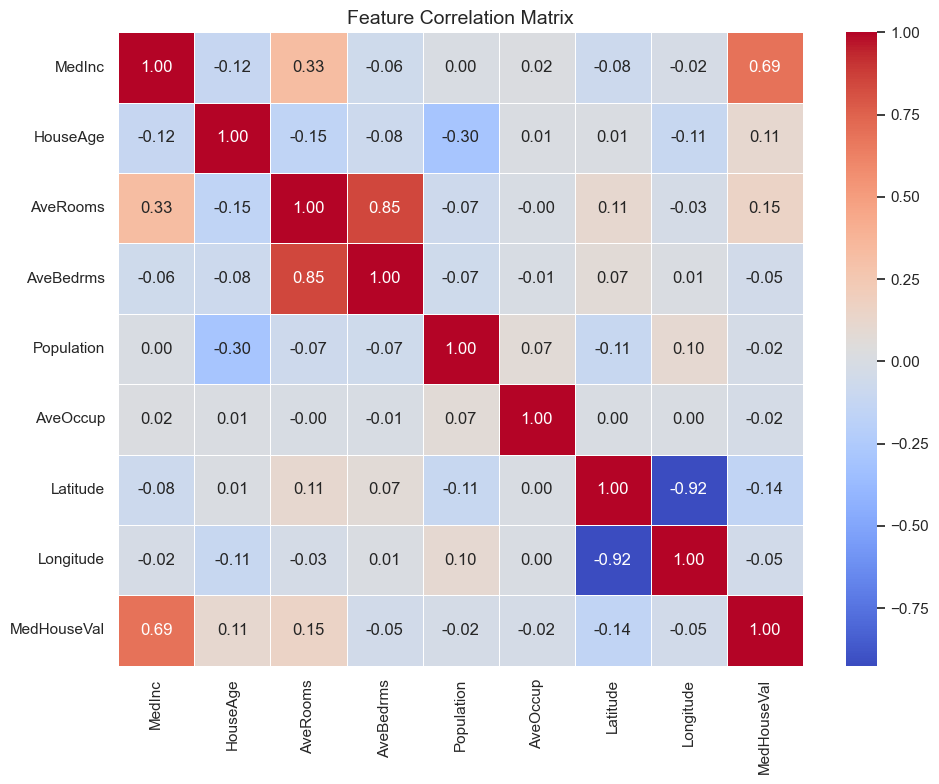

In [29]:
fig, ax = plt.subplots(figsize=(10, 8))

corr = df.corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax)

ax.set_title('Feature Correlation Matrix', fontsize=14)

plt.tight_layout()
plt.savefig('images/correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

## Observations from Feature Correlation Matrix

- Median income (MedInc) has the strongest relationship with the target at 0.69. The remaining features are much weaker, with most correlations below 0.15 in absolute value. HouseAge and AveRooms show small positive correlations, while AveOccup and Population have almost no direct relationship with house value.

- AveRooms and AveBedrms are highly correlated at 0.85, meaning they carry similar information. For a linear model this makes it harder to isolate the contribution of each feature, a multicollinearity concern worth flagging at evaluation.

- Latitude and Longitude have a strong negative correlation of -0.92 and move together across the dataset. Using them as separate features introduces redundancy. Combining them into a single distance-based feature would be a cleaner approach.

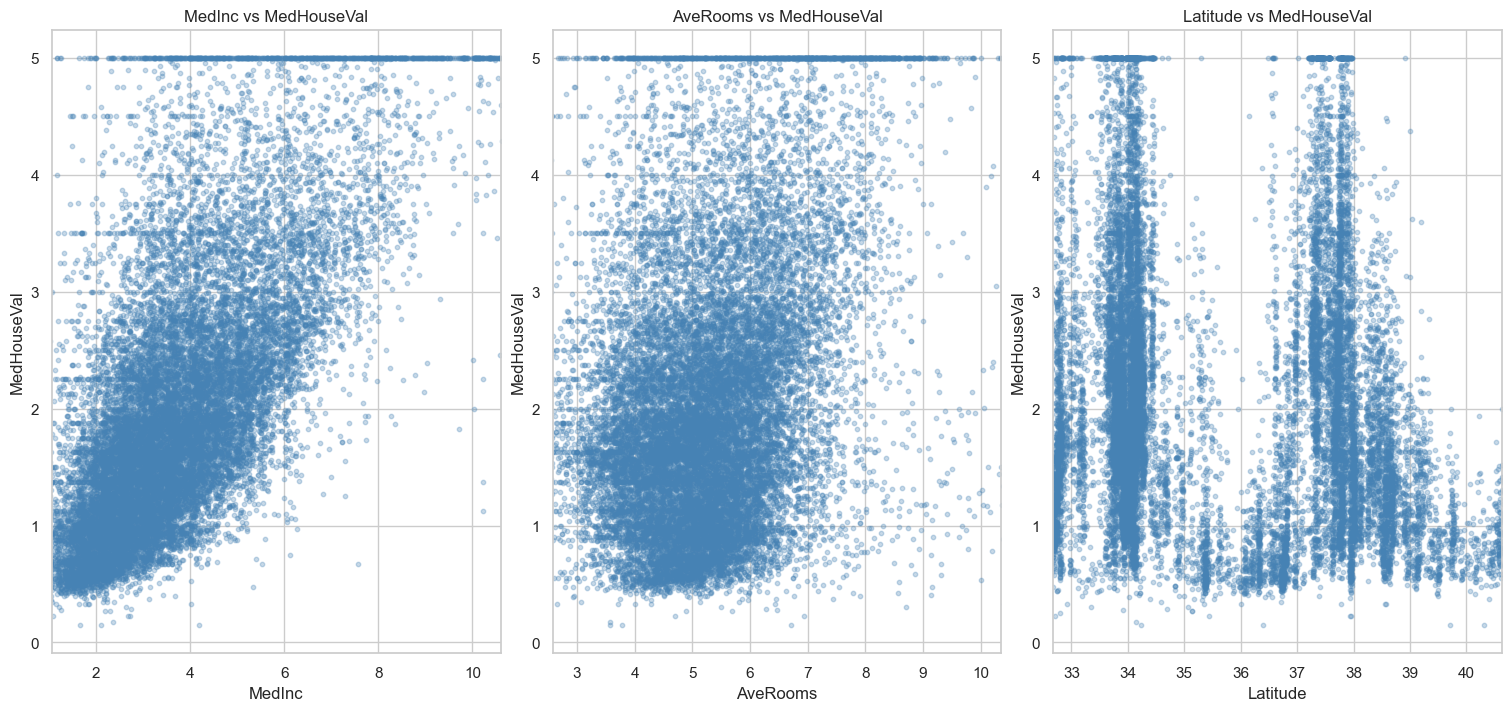

In [30]:
top_features = (corr['MedHouseVal']
                .drop('MedHouseVal')
                .abs()
                .sort_values(ascending=False)
                .head(3)
                .index
                .tolist())

fig, axes = plt.subplots(1, 3, figsize=(15, 7), constrained_layout=True)

for i, feature in enumerate(top_features):
    axes[i].scatter(df[feature], df['MedHouseVal'],
                    alpha=0.3, s=10, color='steelblue')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('MedHouseVal')
    axes[i].set_title(f'{feature} vs MedHouseVal')
    axes[i].set_xlim(df[feature].quantile(0.01), df[feature].quantile(0.99))

plt.savefig('images/top3_scatter.png', dpi=120, bbox_inches='tight')
plt.show()

## Observations from Feature Scatter Plots

- Median income shows the clearest relationship with median house value. As income increases, house values generally increase as well. However, the spread of values becomes wider at higher income levels, indicating greater variation and potentially less accurate predictions in this region. The upper limit at $500k is also visible as a concentration of points along the maximum target value.

- Average rooms per household shows a weak positive relationship with house value. While properties with more rooms tend to have higher values on average, the large amount of scatter suggests that room count alone is not a strong predictor of house prices.

- Latitude exhibits a slight negative relationship with house value, with higher latitudes generally associated with lower-priced properties. The vertical bands in the plot indicate that latitude values are recorded at discrete intervals. Despite the overall trend, there is substantial variation, suggesting that latitude on its own provides limited predictive power.

## Preprocessing

Before training, we separate the features from the target, split into training and test sets, and scale the features.

The split must happen **before** scaling. Fitting the scaler on the full dataset allows test-set information to influence the training process, which is data leakage and produces optimistic evaluation metrics.

In [31]:
X = df.drop(columns='MedHouseVal')
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Train: (16512, 8) | Test: (4128, 8)


### Scaling

`StandardScaler` subtracts the mean and divides by the standard deviation for each feature. It is fitted on the training set only. The test set is then transformed using those same training statistics.

In [32]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f'Feature means (should be ~0): {X_train.mean(axis=0).round(6)}')
print(f'Feature stds  (should be ~1): {X_train.std(axis=0).round(6)}')

Feature means (should be ~0): [-0. -0. -0. -0. -0.  0.  0.  0.]
Feature stds  (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1.]


## Observations from Preprocessing

- The dataset was split 80/20 into 16,512 training rows and 4,128 test rows. `random_state=42` ensures the split is identical on every run.
- `StandardScaler` was fitted on the training set only, then applied to both sets. The scaler has no knowledge of the test distribution, so there is no data leakage.
- After scaling, all training features have a mean of approximately 0 and a standard deviation of approximately 1. This puts features like `MedInc` (range ~0.5-15) and `AveRooms` (range ~1-141) on the same scale, preventing high-magnitude features from dominating the regression coefficients.

## Model Training

We fit a `LinearRegression` model on the scaled training data. Linear regression finds the set of coefficients that minimises the sum of squared residuals (Ordinary Least Squares). For this dataset it is a strong interpretable baseline before considering regularisation or non-linear models.

In [33]:
model = LinearRegression()
model.fit(X_train, y_train)

print(f'Intercept: {model.intercept_:.4f}')

Intercept: 2.0719


### Coefficients

Each coefficient shows the change in predicted median house value (in $100,000s) for a one-standard-deviation increase in that feature, holding all others constant. Sorting by absolute magnitude ranks features by their influence on the prediction.

In [34]:
coef_df = pd.DataFrame({
    'Feature': housing.feature_names,
    'Coefficient': model.coef_
})
coef_df['Abs'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs', ascending=False).drop(columns='Abs').reset_index(drop=True)

coef_df

,Feature,Coefficient
0,Latitude,-0.896929
1,Longitude,-0.869842
2,MedInc,0.854383
3,AveBedrms,0.339259
4,AveRooms,-0.294410
5,HouseAge,0.122546
6,AveOccup,-0.040829
7,Population,-0.002308


## Observations from Model Training

- `MedInc` has the largest positive coefficient by a significant margin, consistent with the correlation heatmap. Higher median income is the strongest driver of predicted house value.
- `Latitude` carries a large negative coefficient: moving north in California is associated with lower house values, reflecting the concentration of high-value properties in Southern California and the Bay Area.
- `AveOccup` is negative: districts with more occupants per household tend to have lower median values, a proxy for overcrowding.
- Coefficients are in units of scaled features. They reflect relative influence within this model, not raw real-world effect sizes.
- The intercept represents the predicted value when all scaled features equal zero (i.e. a district at the mean of every feature).

## Evaluation

We evaluate the model on both the training and test sets. Comparing the two reveals whether the model generalises well or is overfitting. We report RMSE, MAE, and R². A single metric never tells the full story.

In [35]:
y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
test_rmse  = np.sqrt(mean_squared_error(y_test,  y_pred_test))
train_mae  = mean_absolute_error(y_train, y_pred_train)
test_mae   = mean_absolute_error(y_test,  y_pred_test)
train_r2   = r2_score(y_train, y_pred_train)
test_r2    = r2_score(y_test,  y_pred_test)

print(f"{'Metric':<8} {'Train':>10} {'Test':>10} {'Gap':>10}")
print('-' * 42)
print(f"{'RMSE':<8} {train_rmse:>10.4f} {test_rmse:>10.4f} {test_rmse - train_rmse:>+10.4f}")
print(f"{'MAE':<8} {train_mae:>10.4f} {test_mae:>10.4f} {test_mae - train_mae:>+10.4f}")
print(f"{'R²':<8} {train_r2:>10.4f} {test_r2:>10.4f} {test_r2 - train_r2:>+10.4f}")

Metric        Train       Test        Gap
------------------------------------------
RMSE         0.7197     0.7456    +0.0259
MAE          0.5286     0.5332    +0.0046
R²           0.6126     0.5758    -0.0368


### Diagnostic Plots

The actual vs predicted plot shows how closely predictions track true values. Points near the diagonal indicate accurate predictions. The residual plot checks whether errors are randomly scattered around zero, a key assumption of OLS (homoscedasticity).

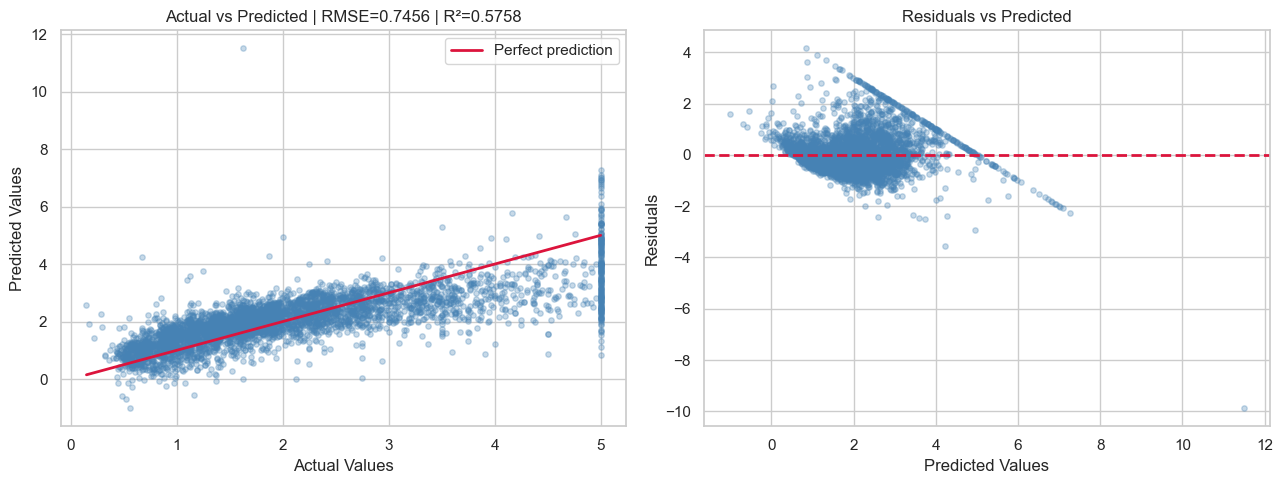

In [36]:
residuals = y_test - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, y_pred_test, alpha=0.3, color='steelblue', s=15)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             color='crimson', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Values')
axes[0].set_ylabel('Predicted Values')
axes[0].set_title(f'Actual vs Predicted | RMSE={test_rmse:.4f} | R²={test_r2:.4f}')
axes[0].legend()

axes[1].scatter(y_pred_test, residuals, alpha=0.3, color='steelblue', s=15)
axes[1].axhline(0, color='crimson', linewidth=2, linestyle='--')
axes[1].set_xlabel('Predicted Values')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residuals vs Predicted')

plt.tight_layout()
plt.savefig('images/evaluation_plots.png', dpi=120, bbox_inches='tight')
plt.show()

## Observations from Evaluation

- Test RMSE and MAE are close to their training counterparts. The gap is small, so the model generalises well and is not overfitting.
- R² of approximately 0.60 means the model explains around 60% of the variance in median house values. `MedInc` drives much of this; the remaining features add limited signal.
- The actual vs predicted plot shows the model performs reasonably for mid-range properties but consistently underpredicts high-value properties. The $500k data censoring is partly responsible: the model cannot learn the true distribution above that threshold.
- The residual plot shows a fan-shaped pattern (heteroscedasticity): variance in errors increases at higher predicted values. This violates the homoscedasticity assumption of OLS. A log transformation of the target would likely improve residual behaviour.

## Conclusions

### What the model achieves
The linear regression model predicts median house values with an RMSE of approximately 0.73 ($73,000) and an R² of approximately 0.60. With no feature engineering, this is a solid baseline. It correctly identifies median income as the dominant driver and captures broad geographic patterns through latitude and longitude.

### Limitations
- **Data censoring:** values above $500,000 are capped at 5.0. The model systematically underpredicts high-value properties because it cannot learn the true upper distribution.
- **Heteroscedasticity:** prediction error grows with house value, suggesting the linear assumption breaks down at the high end. A log transformation of `MedHouseVal` would likely improve residual behaviour.
- **Multicollinearity:** `AveRooms` and `AveBedrms` are highly correlated (0.85), as are `Latitude` and `Longitude` (-0.92). This inflates coefficient variance and makes individual feature contributions harder to interpret.

### Next steps
- Apply a log transformation to `MedHouseVal`, refit, and compare RMSE and residual structure
- Try Ridge regression to reduce the impact of multicollinearity
- Engineer a combined location feature (e.g. distance from San Francisco) to replace the raw coordinates